# Muon, Björck and max-derivative quintics as sign iterations
Three odd quintic updates run on the same matrix. Plot 1: spectral-norm error against the exact sign, per iteration $k$. Plot 2: for each polynomial, the singular values of $X_k$ at a few values of $k$ against the input singular values and the target 1. Muon's quintic has $p(1) 
eq 1$, so it does not converge to the sign: its singular values end up in a band around 1. Edit the config and rerun.

In [1]:
import sys
sys.path.insert(0, "..")  # repo root, so ns_core and experiments import

import matplotlib.pyplot as plt
import torch

from ns_core import plots
from experiments.cpwl_operator import CPWLOperatorConfig
from experiments.polynomial_comparison import PolynomialComparisonConfig, run_polynomial_comparison, run_quintic_cpwl, run_cpwl_comparison
%matplotlib inline

In [2]:
cfg = PolynomialComparisonConfig(
    m=128, n=128, rank=None, cond=1e2, sigma_max=1.0,
    polynomials=None,   # None = Muon, Björck, max derivative; or {name: ascending coeffs of x, x^3, x^5}
    k_max=100,           # steps for plot 1
    k_show=[5],  # plot 2: step counts
    eps=None,           # freeze the iterate once its error reaches this; None = 10 machine eps
    dtype=torch.float64, device="cpu", seed=0,
)
res = run_polynomial_comparison(cfg)

## Plot 1: error against iterations

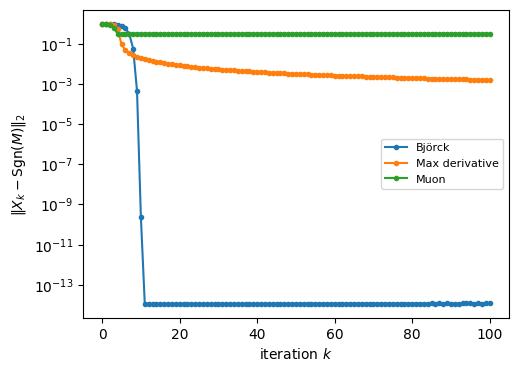

In [3]:
names = {name: name for name in res["error"]}
plots.plot_error_curves(
    res["error"], labels=names,
    eps=cfg.eps,           # None = no markers or line
    show_first_hit=True,   # mark the first step with error <= eps
    show_eps_line=True,    # horizontal line at eps
    k_plot=None,           # last step shown (None = all)
);

## Plot 2: spectrum convergence toward the sign

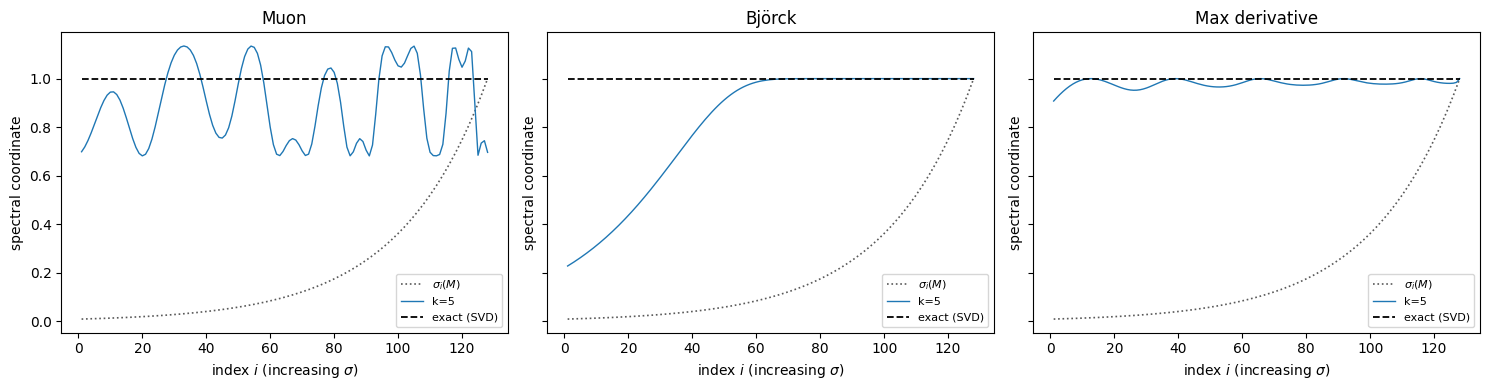

In [4]:
fig, axs = plt.subplots(1, len(res["coords"]), figsize=(5 * len(res["coords"]), 4), sharey=True)
for ax, (name, coords) in zip(axs, res["coords"].items()):
    plots.plot_spectrum(res["sigma"], res["target"], coords, ax=ax, xaxis="index")
    ax.set_title(name)
fig.tight_layout()

## CPWL operator on the max-derivative quintic
Every internal sign call runs exactly `n_iters` steps of the quintic; the clip operator is compared with the exact one (relative Frobenius error).

## CPWL operator through each polynomial (as in exp6)
The same three polynomials as the sign map inside the CPWL operator. Plot 1: relative Frobenius error of the operator against the exact one, per step count $k$. Plot 2: the operator's output spectrum at a few values of $k$ against the input singular values and the exact profile.

In [5]:
cpwl_cfg = CPWLOperatorConfig(
    m=64, n=48, rank=48, cond=1e2, sigma_max=1.0,
    profile="clip", alpha=0.2, beta=0.5,
    eps=1e-8,   # error run stops once the operator error reaches this; None = 10 machine eps
    dtype=torch.float64, device="cpu", seed=0,
)
res_cpwl = run_cpwl_comparison(cpwl_cfg, polynomials=None, k_max=20, k_show=[1, 2, 4, 8])

### CPWL plot 1: error against iterations

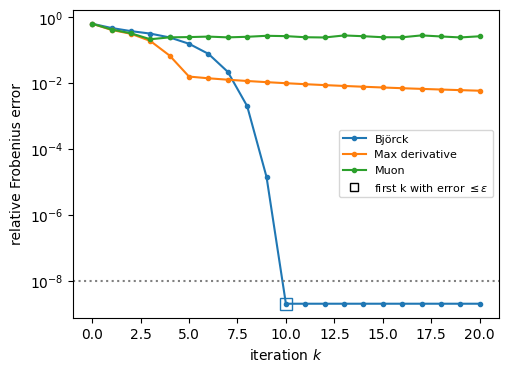

In [6]:
plots.plot_error_curves(
    res_cpwl["error"], labels={n: n for n in res_cpwl["error"]}, ylabel="relative Frobenius error",
    eps=cpwl_cfg.eps,      # None = no markers or line
    show_first_hit=True,   # mark the first step with error <= eps
    show_eps_line=True,    # horizontal line at eps
    k_plot=None,           # last step shown (None = all)
);

### CPWL plot 2: output spectrum

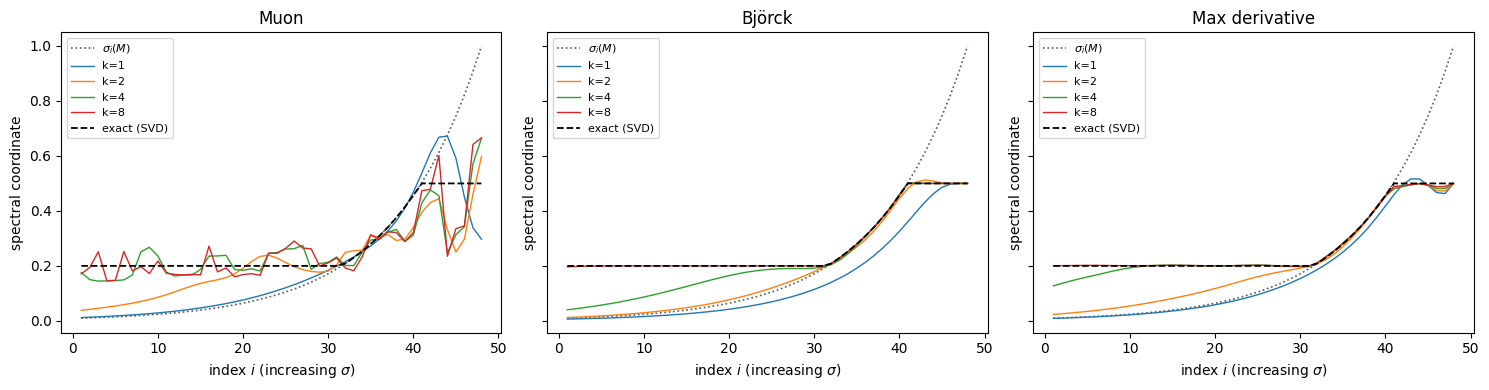

In [7]:
fig, axs = plt.subplots(1, len(res_cpwl["coords"]), figsize=(5 * len(res_cpwl["coords"]), 4), sharey=True)
for ax, (name, coords) in zip(axs, res_cpwl["coords"].items()):
    plots.plot_spectrum(res_cpwl["sigma"], res_cpwl["target"], coords, ax=ax, xaxis="index")
    ax.set_title(name)
fig.tight_layout()